Saving rice_yield_data_large.csv to rice_yield_data_large (4).csv
First 5 rows of dataset:
   Rainfall  Temperature  Humidity  Fertilizer  Area  Yield
0      1200           28        80         100   2.5    4.2
1      1000           27        75          90   2.0    3.8
2      1100           29        78          95   2.3    4.0
3      1300           30        82         110   2.7    4.5
4       900           26        70          85   1.8    3.5

Model Performance:
Mean Absolute Error: 0.04
R2 Score: 0.99

Predicted Yield (tons/hectare): 3.94


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


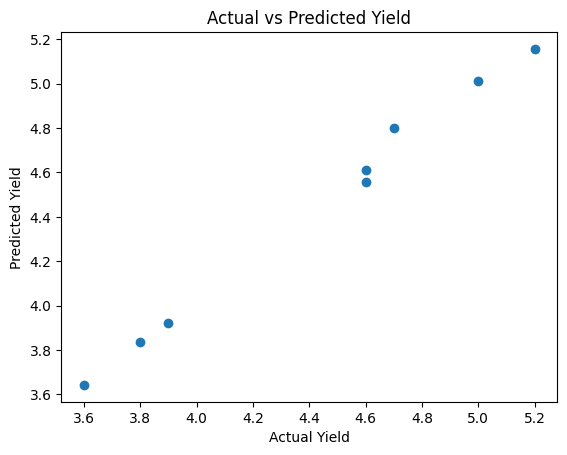

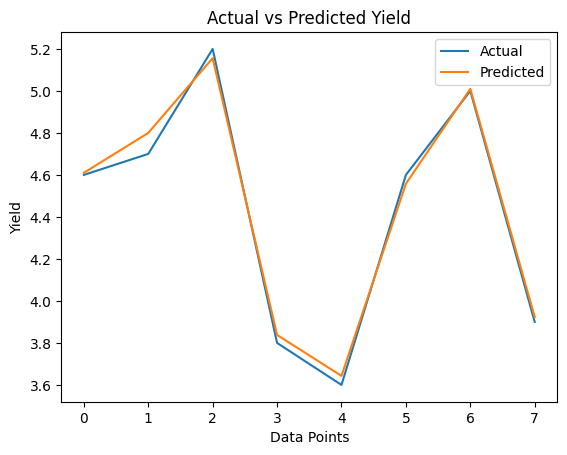

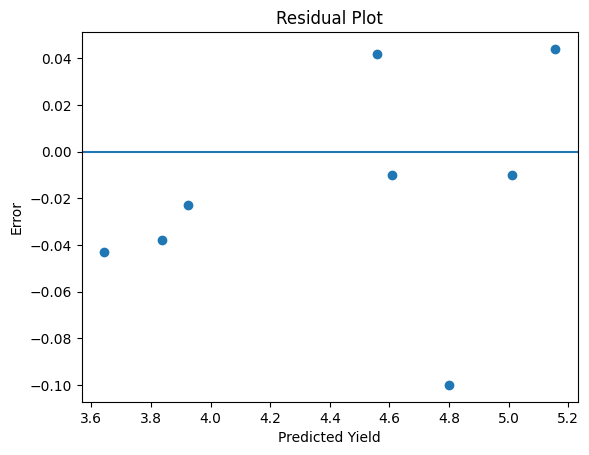

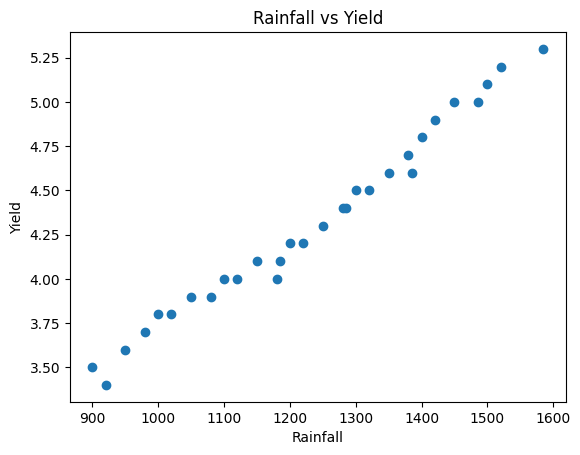

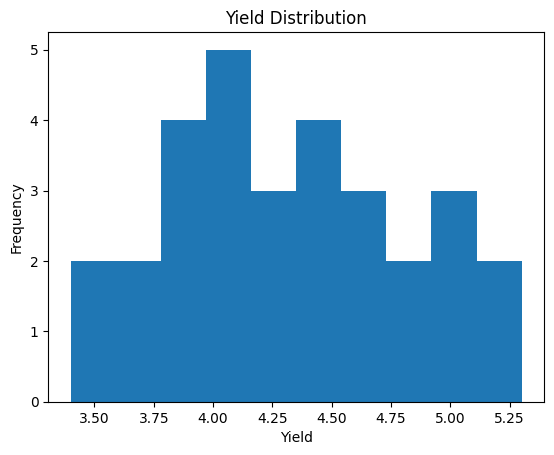

In [ ]:
# ================================
# 🌾 CROP YIELD PREDICTION USING AI
# ================================

# Step 0: Upload Dataset
from google.colab import files
files.upload()

# ================================
# Step 1: Import Libraries
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# ================================
# Step 2: Load Dataset
# ================================
data = pd.read_csv('rice_yield_data_large.csv')

print("First 5 rows of dataset:")
print(data.head())

# ================================
# Step 3: Define Features & Target
# ================================
X = data[["Rainfall", "Temperature", "Humidity", "Fertilizer", "Area"]]
y = data["Yield"]

# ================================
# Step 4: Split Data
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# ================================
# Step 5: Feature Scaling
# ================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================================
# Step 6: Train Model
# ================================
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ================================
# Step 7: Predictions
# ================================
y_pred = model.predict(X_test)

# ================================
# Step 8: Model Evaluation
# ================================
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("Mean Absolute Error:", round(mae, 2))
print("R2 Score:", round(r2, 2))

# ================================
# Step 9: Predict New Data
# ================================
new_data = np.array([[500, 21, 70, 145, 2.0]])
new_data = scaler.transform(new_data)

predicted_yield = model.predict(new_data)

print("\nPredicted Yield (tons/hectare):", round(predicted_yield[0], 2))

# ================================
# Step 10: Graphs
# ================================

# 📊 1. Actual vs Predicted Scatter Plot
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")
plt.show()

# 📈 2. Line Graph (Comparison)
plt.figure()
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Yield")
plt.xlabel("Data Points")
plt.ylabel("Yield")
plt.show()

# 📉 3. Residual Plot
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Yield")
plt.ylabel("Error")
plt.title("Residual Plot")
plt.show()

# 🌧️ 4. Rainfall vs Yield
plt.figure()
plt.scatter(data["Rainfall"], data["Yield"])
plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.title("Rainfall vs Yield")
plt.show()

# 📊 5. Yield Distribution
plt.figure()
plt.hist(data["Yield"], bins=10)
plt.title("Yield Distribution")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.show()

# ================================
# ✅ END OF PROJECT
# ================================
